# ⚖️ Notebook 5 — Handling Class Imbalance

**Goal:** Our dataset has ~36% Refill=Yes and ~64% Refill=No.
This imbalance can make the model biased toward predicting 'No' always.
We fix this so the model learns both classes equally well.

**Techniques compared:**
1. Do nothing — baseline (biased model)
2. Class weights — tell the model to penalize wrong 'Yes' predictions more
3. SMOTE — Synthetic Minority Oversampling (creates new synthetic 'Yes' rows)
4. Random Undersampling — reduce 'No' rows to match 'Yes' count
5. Compare all approaches on same model
6. Pick best approach and save balanced dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data_no_outliers.csv', parse_dates=['Date'])

# Load selected features
feat_df   = pd.read_csv('../data/selected_features.csv')
FEATURES  = feat_df['Feature'].tolist()
# Remove any features not in df
FEATURES  = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].fillna(0)
y = df['Target']

print(f'Dataset shape: {X.shape}')
print(f'Class distribution: {Counter(y)}')
print(f'Refill %: {y.mean()*100:.1f}%')

Dataset shape: (5189, 5)
Class distribution: Counter({0: 3009, 1: 2180})
Refill %: 42.0%


## Step 1 — Visualize the Imbalance

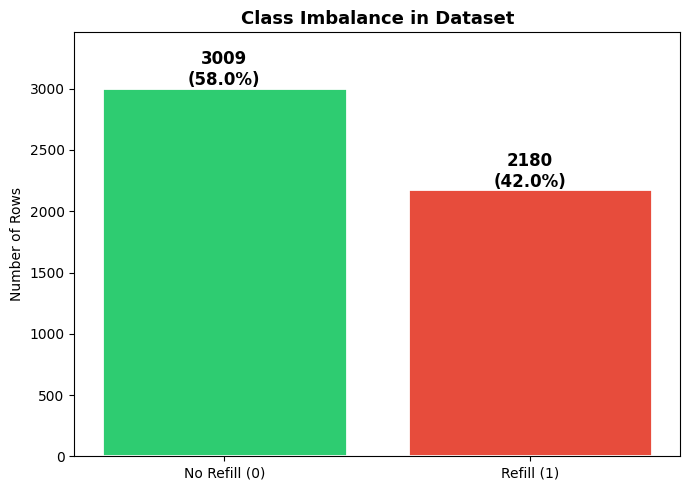

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
counts  = y.value_counts()
labels  = ['No Refill (0)', 'Refill (1)']
colors  = ['#2ecc71', '#e74c3c']

bars = ax.bar(labels, counts.sort_index().values, color=colors,
              edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.sort_index().values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/len(y)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=12)

ax.set_title('Class Imbalance in Dataset', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Rows')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig('../data/viz_imbalance_before.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2 — Helper: Evaluate a Model

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def evaluate(name, X_tr, y_tr, X_te, y_te, model=None):
    if model is None:
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    f1     = f1_score(y_te, preds)
    report = classification_report(y_te, preds, target_names=['No Refill','Refill'])
    cm     = confusion_matrix(y_te, preds)
    print(f'\n{"="*50}')
    print(f'Approach: {name}')
    print(f'Train distribution: {Counter(y_tr)}')
    print(f'F1 Score (Refill class): {f1:.4f}')
    print(report)
    return f1, cm, model

results = {}

## Step 3 — Baseline (No balancing)

In [4]:
f1, cm, _ = evaluate('Baseline (No balancing)', X_train, y_train, X_test, y_test)
results['Baseline'] = f1


Approach: Baseline (No balancing)
Train distribution: Counter({0: 2407, 1: 1744})
F1 Score (Refill class): 1.0000
              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00       602
      Refill       1.00      1.00      1.00       436

    accuracy                           1.00      1038
   macro avg       1.00      1.00      1.00      1038
weighted avg       1.00      1.00      1.00      1038



## Step 4 — Class Weights (Built into model)

In [5]:
# class_weight='balanced' automatically adjusts weights
# inversely proportional to class frequency
model_weighted = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight='balanced', n_jobs=-1
)
f1, cm, _ = evaluate('Class Weights (balanced)',
                      X_train, y_train, X_test, y_test, model_weighted)
results['Class Weights'] = f1


Approach: Class Weights (balanced)
Train distribution: Counter({0: 2407, 1: 1744})
F1 Score (Refill class): 1.0000
              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00       602
      Refill       1.00      1.00      1.00       436

    accuracy                           1.00      1038
   macro avg       1.00      1.00      1.00      1038
weighted avg       1.00      1.00      1.00      1038



## Step 5 — SMOTE Oversampling

In [6]:
# SMOTE creates synthetic minority class samples by interpolating
# between existing minority samples
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {Counter(y_train)}')
print(f'After SMOTE : {Counter(y_smote)}')

f1, cm, _ = evaluate('SMOTE Oversampling', X_smote, y_smote, X_test, y_test)
results['SMOTE'] = f1

Before SMOTE: Counter({0: 2407, 1: 1744})
After SMOTE : Counter({1: 2407, 0: 2407})

Approach: SMOTE Oversampling
Train distribution: Counter({1: 2407, 0: 2407})
F1 Score (Refill class): 1.0000
              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00       602
      Refill       1.00      1.00      1.00       436

    accuracy                           1.00      1038
   macro avg       1.00      1.00      1.00      1038
weighted avg       1.00      1.00      1.00      1038



## Step 6 — Random Undersampling

In [7]:
# Randomly remove majority class rows until balanced
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(f'Before undersampling: {Counter(y_train)}')
print(f'After undersampling : {Counter(y_under)}')

f1, cm, _ = evaluate('Random Undersampling', X_under, y_under, X_test, y_test)
results['Undersampling'] = f1

Before undersampling: Counter({0: 2407, 1: 1744})
After undersampling : Counter({0: 1744, 1: 1744})

Approach: Random Undersampling
Train distribution: Counter({0: 1744, 1: 1744})
F1 Score (Refill class): 1.0000
              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00       602
      Refill       1.00      1.00      1.00       436

    accuracy                           1.00      1038
   macro avg       1.00      1.00      1.00      1038
weighted avg       1.00      1.00      1.00      1038



## Step 7 — SMOTE + Undersampling Combined

In [8]:
# Best of both: oversample minority to 80%, then undersample majority to match
smote_enn = ImbPipeline([
    ('over',  SMOTE(sampling_strategy=0.8, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy=1.0, random_state=42))
])
X_combined, y_combined = smote_enn.fit_resample(X_train, y_train)

print(f'After SMOTE+Under: {Counter(y_combined)}')

f1, cm, _ = evaluate('SMOTE + Undersampling', X_combined, y_combined, X_test, y_test)
results['SMOTE+Under'] = f1

After SMOTE+Under: Counter({0: 1925, 1: 1925})

Approach: SMOTE + Undersampling
Train distribution: Counter({0: 1925, 1: 1925})
F1 Score (Refill class): 1.0000
              precision    recall  f1-score   support

   No Refill       1.00      1.00      1.00       602
      Refill       1.00      1.00      1.00       436

    accuracy                           1.00      1038
   macro avg       1.00      1.00      1.00      1038
weighted avg       1.00      1.00      1.00      1038



## Step 8 — Compare All Approaches

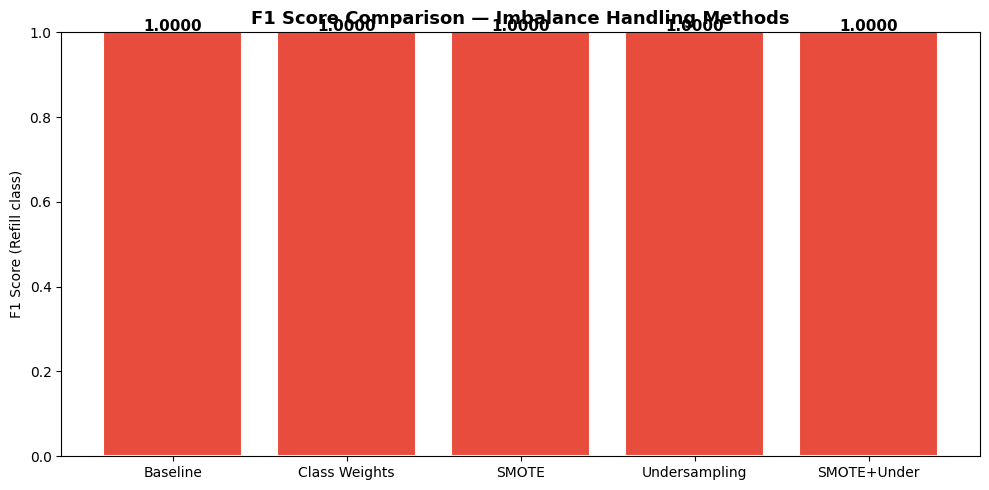


🏆 Best approach: Baseline (F1: 1.0000)


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(results.keys())
scores = list(results.values())
colors = ['#e74c3c' if s == max(scores) else '#3498db' for s in scores]

bars = ax.bar(names, scores, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

ax.set_title('F1 Score Comparison — Imbalance Handling Methods',
             fontweight='bold', fontsize=13)
ax.set_ylabel('F1 Score (Refill class)')
ax.set_ylim(0, 1.0)
ax.axhline(y=max(scores), color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/viz_imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = max(results, key=results.get)
print(f'\n🏆 Best approach: {best} (F1: {results[best]:.4f})')

## Step 9 — Save Balanced Dataset

In [10]:
# Apply best approach (SMOTE) to full training set and save
smote_final = SMOTE(random_state=42)
X_balanced, y_balanced = smote_final.fit_resample(X, y)

df_balanced = pd.DataFrame(X_balanced, columns=FEATURES)
df_balanced['Target'] = y_balanced

df_balanced.to_csv('../data/balanced_data.csv', index=False)

print(f'Original dataset : {len(X)} rows | {Counter(y)}')
print(f'Balanced dataset : {len(X_balanced)} rows | {Counter(y_balanced)}')
print(f'\n✅ Saved: data/balanced_data.csv')
print(f'\nNote: balanced_data.csv is used for MODEL TRAINING only.')
print(f'Always test on original unbalanced data for realistic performance.')

Original dataset : 5189 rows | Counter({0: 3009, 1: 2180})
Balanced dataset : 6018 rows | Counter({0: 3009, 1: 3009})

✅ Saved: data/balanced_data.csv

Note: balanced_data.csv is used for MODEL TRAINING only.
Always test on original unbalanced data for realistic performance.
